In [1]:
import urllib.request
import pandas as pd

In [2]:
url = "https://data.seattle.gov/resource/tmmm-ytt6.csv?$where=checkoutyear=2018&$limit=10000"
checkout_file = "checkout.csv"
urllib.request.urlretrieve(url, checkout_file)

('checkout.csv', <http.client.HTTPMessage at 0x119d101d0>)

In [3]:
checkouts_df = pd.read_csv(checkout_file)

In [4]:
checkouts_df

,usageclass,checkouttype,materialtype,checkoutyear,checkoutmonth,checkouts,title,isbn,creator,subjects,publisher,publicationyear
0,Digital,OverDrive,EBOOK,2018,1,22,Enemy of the State,NaN,Vince Flynn,"Fiction, Literature, Thriller","Simon & Schuster, Inc.",2017
1,Digital,Hoopla,TELEVISION,2018,1,1,Newspaper Mom / Cucumber in Rio / Donut Raffle,NaN,NaN,Children's,DHX Media,NaN
2,Physical,Horizon,SOUNDDISC,2018,1,1,Mono / the Mavericks.,NaN,Mavericks (Musical group),Country music 2011 2020,"Valory,",[2015]
3,Digital,OverDrive,EBOOK,2018,1,2,Anna Karenina,NaN,Leo Tolstoy,"Classic Literature, Fiction, Literature","Penguin Group (USA), Inc.",2009
4,Digital,OverDrive,EBOOK,2018,1,1,"Dragon: Vlad Series, Book 8",NaN,Steven Brust,"Fantasy, Fiction",Macmillan Publishers,2015
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Digital,OverDrive,EBOOK,2018,1,1,"Immortal: Fallen Angels Series, Book 6",NaN,J.R. Ward,"Fantasy, Fiction, Romance","Penguin Group (USA), Inc.",2014
9996,Digital,OverDrive,EBOOK,2018,1,1,The Price of Silence,NaN,Kate Wilhelm,"Fiction, Suspense, Thriller","Harlequin Enterprises, Ltd.",2011
9997,Digital,Freegal,SONG,2018,1,1,Desert Hideaway,NaN,NaN,NaN,NaN,NaN
9998,Physical,Horizon,BOOK,2018,1,3,Waistcoats & weaponry / Gail Carriger.,NaN,"Carriger, Gail","Boarding schools Fiction, Schools Fiction, Eti...","Little, Brown and Company,",2014.


In [5]:
checkouts_df.shape

(10000, 12)

In [6]:
checkouts_df["checkouts"].min()

1

In [7]:
checkouts_df["checkouts"].max()

540

In [8]:
checkouts_df["checkouts"].median()

1.0

In [9]:
checkouts_df["materialtype"].unique()

array(['EBOOK', 'TELEVISION', 'SOUNDDISC', 'BOOK', 'AUDIOBOOK', 'COMIC',
       'MOVIE', 'SONG', 'MUSIC', 'MAGAZINE', 'VIDEODISC', 'SOUNDREC',
       'SOUNDDISC, VIDEODISC', 'CR', 'LARGEPRINT', 'ER, SOUNDDISC',
       'ATLAS', 'ER', 'MAP', 'VIDEOCASS, VIDEODISC', 'REGPRINT', 'VIDEO',
       'SOUNDCASS', 'ER, VIDEODISC'], dtype=object)

In [10]:
checkouts_df["publisher"].unique()

array(['Simon & Schuster, Inc.', 'DHX Media', 'Valory,', ...,
       'Zhong xin chu ban she,', 'Gibbs Smith', 'HighBridge,'],
      dtype=object)

In [11]:
checkouts_df[checkouts_df["publisher"] == "DHX Media"]

,usageclass,checkouttype,materialtype,checkoutyear,checkoutmonth,checkouts,title,isbn,creator,subjects,publisher,publicationyear
1,Digital,Hoopla,TELEVISION,2018,1,1,Newspaper Mom / Cucumber in Rio / Donut Raffle,NaN,NaN,Children's,DHX Media,NaN
1906,Digital,Hoopla,MOVIE,2018,1,2,Paddington's Birthday Bonanza,NaN,NaN,"Animated, Children's, Comedy, Family, Feature ...",DHX Media,NaN


In [50]:
checkouts_df["materialtype"].value_counts()

materialtype
BOOK                    4268
EBOOK                   2084
AUDIOBOOK                857
SOUNDDISC                839
VIDEODISC                806
SONG                     707
MUSIC                    139
MOVIE                     94
TELEVISION                85
COMIC                     62
SOUNDDISC, VIDEODISC      10
MAGAZINE                  10
SOUNDREC                   8
REGPRINT                   7
VIDEO                      5
CR                         4
ER, SOUNDDISC              3
ER                         3
MAP                        3
ATLAS                      2
LARGEPRINT                 1
VIDEOCASS, VIDEODISC       1
SOUNDCASS                  1
ER, VIDEODISC              1
Name: count, dtype: int64

<Axes: ylabel='materialtype'>

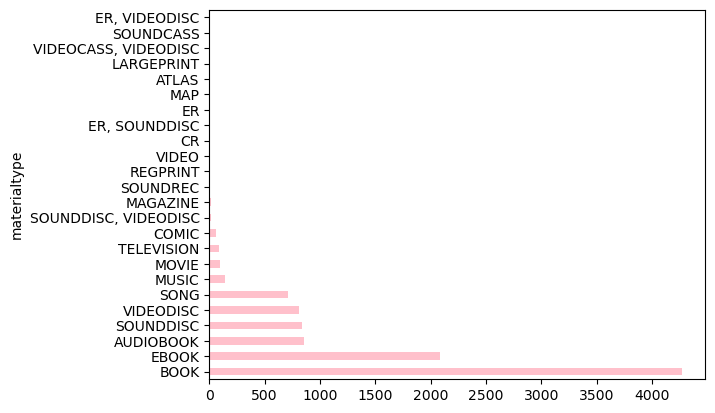

In [48]:
checkouts_df["materialtype"].value_counts().plot(kind="barh", color="pink")

<Axes: >

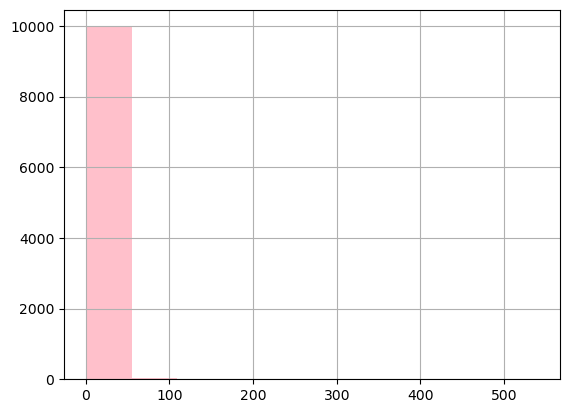

In [54]:
checkouts_df["checkouts"].hist(color="pink")

<Axes: >

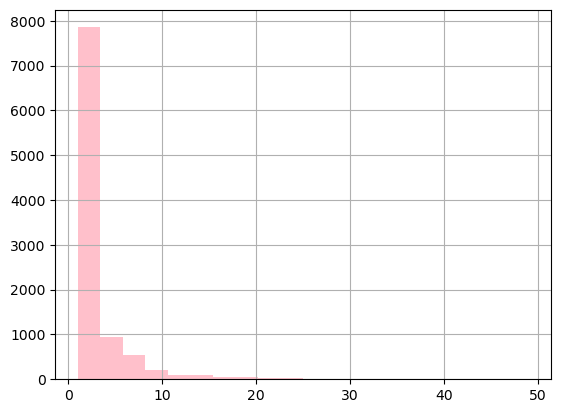

In [46]:
checkouts_df[checkouts_df["checkouts"] < 50 ]["checkouts"].hist(bins=20, color="pink")

In [14]:
checkouts_df["usageclass"].unique()

array(['Digital', 'Physical'], dtype=object)

In [15]:
# Wie ist der Anteil von Physischen im Vergleich zu Digitalen Medienausleihen?
checkouts_df["usageclass"].value_counts()

usageclass
Physical    5979
Digital     4021
Name: count, dtype: int64

<Axes: xlabel='usageclass'>

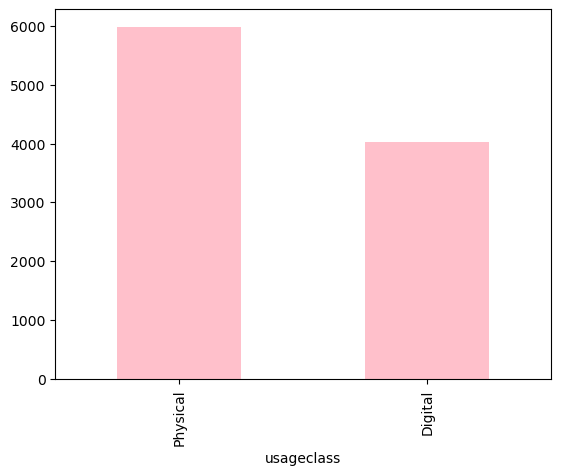

In [44]:
checkouts_df["usageclass"].value_counts().plot(kind="bar", color="pink")

In [17]:
checkouts_df["publicationyear"].unique()

array(['2017', nan, '[2015]', '2009', '2015', '2012', '2000.', '2013',
       '2008', '2018', '2014', '2016', '[1985]', '[2004]', '2017.',
       '2010', '2012.', '[2011]', '[1990]', '2015.', '2016.', 'p2013.',
       '2006', '[2013]', '[1998]', '[2018]', '1944.', '[2010]', '2011.',
       '2003.', '1992.', '2006.', '[2016]', '2011', '1997.', '1999.',
       '2005', '2007', '2013.', 'p2014.', '1988.', '1994.', '[1986]',
       '2010.', '2002.', '[2017]', '[2001?]', '[2014]', '[1985], ℗1977.',
       '[2000, c2001]', '[2007]', '2009.', '[1987]', '2007.', '2014.',
       '1985, ©1984.', '[2008]', '1989.', '[2000]', '1983.', '[2009]',
       '[2012]', '[1994]', '2008.', '[2010], ©1996.', '[2006]', '[2017].',
       '[2000?]', '[2001]', '2016, [c2015]', '[1990?]', '1972.', 'c2015.',
       '[1999]', 'c2013.', '[2005]', '2005.', 'c2017.', '1985.', '[1956]',
       '[2003]', '[2002]', '[between 1970-1979?]', '[2013].', '1998.',
       '[2009], 2002.', '[1997]', '1995.', '2001.', 'c2007, 2008

In [18]:
checkouts_df["publicationyear"].value_counts()

publicationyear
2017             473
[2017]           417
2013             416
2014             343
[2016]           324
                ... 
1961.              1
[1941]             1
2016, [c2015]      1
[1965-71]          1
1958.              1
Name: count, Length: 263, dtype: int64

In [19]:
checkouts_df["materialtype"].value_counts()

materialtype
BOOK                    4268
EBOOK                   2084
AUDIOBOOK                857
SOUNDDISC                839
VIDEODISC                806
SONG                     707
MUSIC                    139
MOVIE                     94
TELEVISION                85
COMIC                     62
SOUNDDISC, VIDEODISC      10
MAGAZINE                  10
SOUNDREC                   8
REGPRINT                   7
VIDEO                      5
CR                         4
ER, SOUNDDISC              3
ER                         3
MAP                        3
ATLAS                      2
LARGEPRINT                 1
VIDEOCASS, VIDEODISC       1
SOUNDCASS                  1
ER, VIDEODISC              1
Name: count, dtype: int64

<Axes: xlabel='materialtype'>

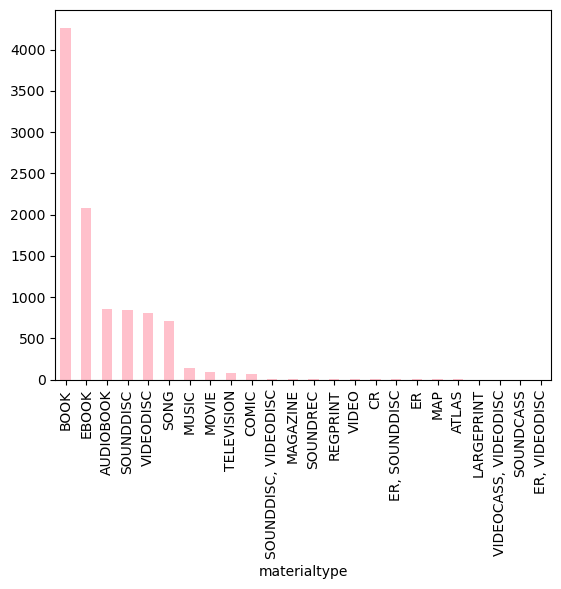

In [20]:
checkouts_df["materialtype"].value_counts().plot(kind="bar", color="pink")